# Temperature Scaling for Calibration

The model produces overconfident predictions (77% are extreme <0.01 or >0.99).  
**Temperature scaling** softens these predictions by dividing logits by a learned temperature T.

- T > 1 → less confident (spreads probabilities)
- T = 1 → original model
- T < 1 → more confident (sharpens probabilities)

We'll find the optimal T on the **validation set** to minimize calibration error.

TEMPERATURE SCALING CALIBRATION
Optimal Temperature: 0.4307
Original NLL (T=1): 0.0453
Calibrated NLL (T=0.43): 0.0362

PREDICTION DISTRIBUTION: Before vs After Calibration

VALIDATION SET:
  Before: 4474 / 6360 extreme predictions (70.3%)
  After:  5985 / 6360 extreme predictions (94.1%)

TEST SET:
  Before: 2718 / 5595 extreme predictions (48.6%)
  After:  4687 / 5595 extreme predictions (83.8%)

PERFORMANCE COMPARISON (PR-AUC / TOP-5% LIFT)
Original Test PR-AUC:   0.7232
Calibrated Test PR-AUC: 0.7232
Difference:             0.0000
Original Top-5% Lift:   7.619
Calibrated Top-5% Lift: 7.619
Difference:             0.000

✓ Calibration plots saved to temperature_scaling_calibration.png


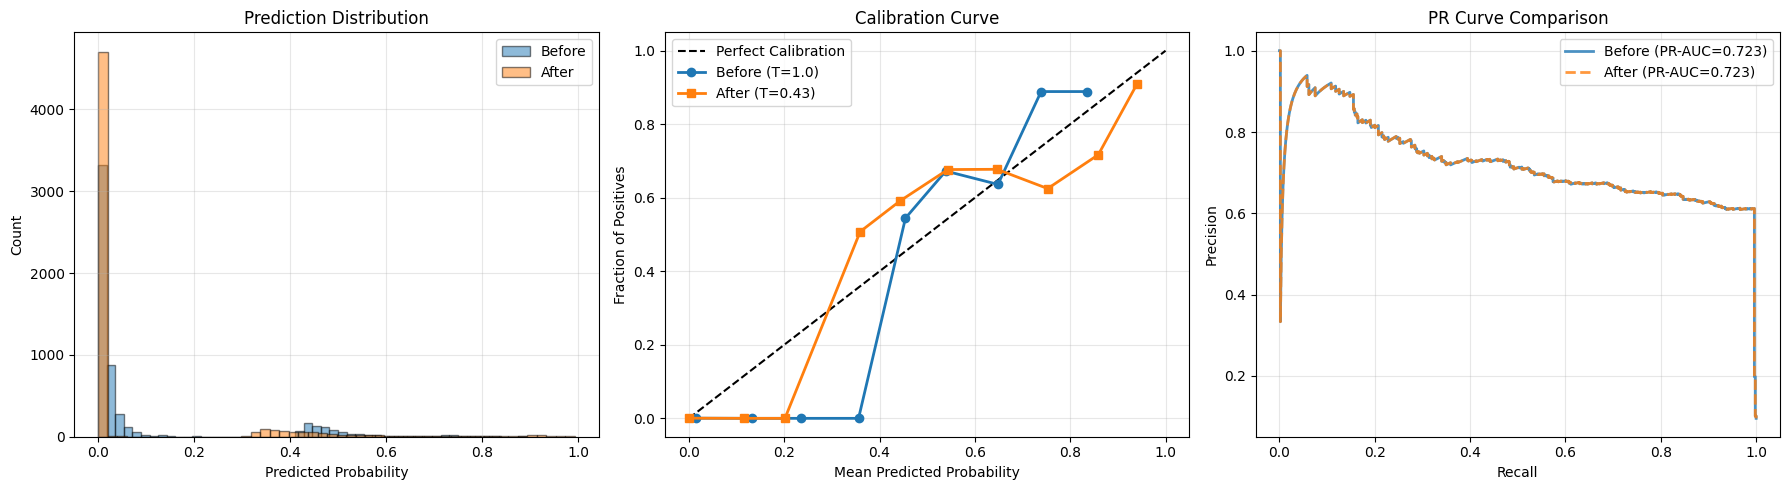


✓ Temperature scaling complete!
  Use temperature=0.4307 in inference to get calibrated probabilities


In [ ]:
from scipy.optimize import minimize
from sklearn.metrics import log_loss, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def topk_lift(y_true, y_prob, k_frac=0.05):
    y_true = np.asarray(y_true).astype(float)
    y_prob = np.asarray(y_prob).astype(float)
    n = len(y_true)
    k = max(1, int(np.ceil(n * k_frac)))
    top_idx = np.argsort(-y_prob)[:k]
    base_rate = y_true.mean() if n > 0 else 0.0
    precision_at_k = y_true[top_idx].mean() if k > 0 else 0.0
    lift = (precision_at_k / base_rate) if base_rate > 0 else 0.0
    return int(k), float(precision_at_k), float(base_rate), float(lift)

# Get validation logits (before sigmoid)
val_loader_calib = NeighborLoader(
    data_graph,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE * 2,
    input_nodes=('customer', data_graph['customer'].val_mask),
    shuffle=False, num_workers=0,
 )

model_sage.eval()
val_logits, val_labels_calib = [], []

with torch.no_grad():
    for b in val_loader_calib:
        b = b.to(device)
        edge_weight_dict = {et: b[et].edge_weight for et in b.edge_types if 'edge_weight' in b[et]}
        out_v = model_sage(b.x_dict, b.edge_index_dict, edge_weight_dict)
        bs_v = b['customer'].batch_size
        logits_v = out_v.squeeze()[:bs_v].cpu()
        y_v = b['customer'].y[:bs_v].cpu()
        lm_v = y_v != -1
        if lm_v.sum() > 0:
            val_logits.extend(logits_v[lm_v].tolist())
            val_labels_calib.extend(y_v[lm_v].tolist())

val_logits = np.array(val_logits)
val_labels_calib = np.array(val_labels_calib)

# Original (uncalibrated) validation probabilities
val_probs_original = 1 / (1 + np.exp(-val_logits))

def temperature_objective(T):
    """Negative log-likelihood (lower is better calibration)."""
    T = max(T[0], 0.01)
    calibrated_probs = 1 / (1 + np.exp(-val_logits / T))
    calibrated_probs = np.clip(calibrated_probs, 1e-7, 1 - 1e-7)
    return log_loss(val_labels_calib, calibrated_probs)

result = minimize(
    temperature_objective,
    x0=[1.0],
    method='Nelder-Mead',
    options={'maxiter': 100, 'xatol': 1e-4},
)
optimal_temperature = max(result.x[0], 0.01)

print("=" * 80)
print("TEMPERATURE SCALING CALIBRATION")
print("=" * 80)
print(f"Optimal Temperature: {optimal_temperature:.4f}")
print(f"Original NLL (T=1): {temperature_objective([1.0]):.4f}")
print(f"Calibrated NLL (T={optimal_temperature:.2f}): {temperature_objective([optimal_temperature]):.4f}")

val_probs_calibrated = 1 / (1 + np.exp(-val_logits / optimal_temperature))

# Get test logits
test_loader_calib = NeighborLoader(
    data_graph,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE * 2,
    input_nodes=('customer', data_graph['customer'].test_mask),
    shuffle=False, num_workers=0,
 )

test_logits, test_labels_calib = [], []
with torch.no_grad():
    for b in test_loader_calib:
        b = b.to(device)
        edge_weight_dict = {et: b[et].edge_weight for et in b.edge_types if 'edge_weight' in b[et]}
        out_t = model_sage(b.x_dict, b.edge_index_dict, edge_weight_dict)
        bs_t = b['customer'].batch_size
        logits_t = out_t.squeeze()[:bs_t].cpu()
        y_t = b['customer'].y[:bs_t].cpu()
        lm_t = y_t != -1
        if lm_t.sum() > 0:
            test_logits.extend(logits_t[lm_t].tolist())
            test_labels_calib.extend(y_t[lm_t].tolist())

test_logits = np.array(test_logits)
test_labels_calib = np.array(test_labels_calib)
test_probs_uncalibrated = 1 / (1 + np.exp(-test_logits))
test_probs_calibrated = 1 / (1 + np.exp(-test_logits / optimal_temperature))

print("\n" + "=" * 80)
print("PREDICTION DISTRIBUTION: Before vs After Calibration")
print("=" * 80)

print("\nVALIDATION SET:")
print(f"  Before: {((val_probs_original < 0.01) | (val_probs_original > 0.99)).sum()} / {len(val_probs_original)} extreme predictions ({((val_probs_original < 0.01) | (val_probs_original > 0.99)).mean():.1%})")
print(f"  After:  {((val_probs_calibrated < 0.01) | (val_probs_calibrated > 0.99)).sum()} / {len(val_probs_calibrated)} extreme predictions ({((val_probs_calibrated < 0.01) | (val_probs_calibrated > 0.99)).mean():.1%})")

print("\nTEST SET:")
print(f"  Before: {((test_probs_uncalibrated < 0.01) | (test_probs_uncalibrated > 0.99)).sum()} / {len(test_probs_uncalibrated)} extreme predictions ({((test_probs_uncalibrated < 0.01) | (test_probs_uncalibrated > 0.99)).mean():.1%})")
print(f"  After:  {((test_probs_calibrated < 0.01) | (test_probs_calibrated > 0.99)).sum()} / {len(test_probs_calibrated)} extreme predictions ({((test_probs_calibrated < 0.01) | (test_probs_calibrated > 0.99)).mean():.1%})")

# PR-AUC / Top-K lift comparison
prec_before, rec_before, _ = precision_recall_curve(test_labels_calib, test_probs_uncalibrated)
prec_after, rec_after, _ = precision_recall_curve(test_labels_calib, test_probs_calibrated)
pr_auc_before = auc(rec_before, prec_before)
pr_auc_after = auc(rec_after, prec_after)

_, _, _, lift5_before = topk_lift(test_labels_calib, test_probs_uncalibrated, k_frac=0.05)
_, _, _, lift5_after = topk_lift(test_labels_calib, test_probs_calibrated, k_frac=0.05)

print("\n" + "=" * 80)
print("PERFORMANCE COMPARISON (PR-AUC / TOP-5% LIFT)")
print("=" * 80)
print(f"Original Test PR-AUC:   {pr_auc_before:.4f}")
print(f"Calibrated Test PR-AUC: {pr_auc_after:.4f}")
print(f"Difference:             {abs(pr_auc_before - pr_auc_after):.4f}")
print(f"Original Top-5% Lift:   {lift5_before:.3f}")
print(f"Calibrated Top-5% Lift: {lift5_after:.3f}")
print(f"Difference:             {abs(lift5_before - lift5_after):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(test_probs_uncalibrated, bins=50, alpha=0.5, label='Before', edgecolor='black')
axes[0].hist(test_probs_calibrated, bins=50, alpha=0.5, label='After', edgecolor='black')
axes[0].set(xlabel='Predicted Probability', ylabel='Count', title='Prediction Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

from sklearn.calibration import calibration_curve
fraction_of_positives_before, mean_predicted_value_before = calibration_curve(
    test_labels_calib, test_probs_uncalibrated, n_bins=10, strategy='uniform'
)
fraction_of_positives_after, mean_predicted_value_after = calibration_curve(
    test_labels_calib, test_probs_calibrated, n_bins=10, strategy='uniform'
)

axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[1].plot(mean_predicted_value_before, fraction_of_positives_before, marker='o', label='Before (T=1.0)', linewidth=2)
axes[1].plot(mean_predicted_value_after, fraction_of_positives_after, marker='s', label=f'After (T={optimal_temperature:.2f})', linewidth=2)
axes[1].set(xlabel='Mean Predicted Probability', ylabel='Fraction of Positives', title='Calibration Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(rec_before, prec_before, lw=2, label=f'Before (PR-AUC={pr_auc_before:.3f})', alpha=0.8)
axes[2].plot(rec_after, prec_after, lw=2, label=f'After (PR-AUC={pr_auc_after:.3f})', linestyle='--', alpha=0.8)
axes[2].set(title='PR Curve Comparison', xlabel='Recall', ylabel='Precision')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('temperature_scaling_calibration.png', dpi=150, bbox_inches='tight')
print("\n✓ Calibration plots saved to temperature_scaling_calibration.png")
plt.show()

print("\n" + "=" * 80)
print("✓ Temperature scaling complete!")
print(f"  Use temperature={optimal_temperature:.4f} in inference to get calibrated probabilities")
print("=" * 80)


TEMPERATURE OPTIONS FOR DIFFERENT USE CASES

The optimal temperature T=0.4307 minimizes calibration error (NLL),
but makes predictions MORE extreme (higher confidence).

For the DEMO application, you may want a higher temperature to prevent
rapid score jumps when adding transactions:


Temperature     Extreme %       Mean Prob       Std Prob        Use Case
-------------------------------------------------------------------------------------
0.4307          83.8%           0.0805          0.2005          Best Calibration
1.00            48.6%           0.0932          0.1866          Original Model
2.00            5.1%            0.1540          0.1631          Smoother (Recommended for Demo)
3.00            0.6%            0.2167          0.1419          Very Smooth
5.00            0.1%            0.3015          0.1088          Extremely Smooth


**Recommendation:**
- Use T=0.4307 for production risk scoring (best calibration)
- Use T=2.0 or T=3.0 for the demo UI (smoother, less jum

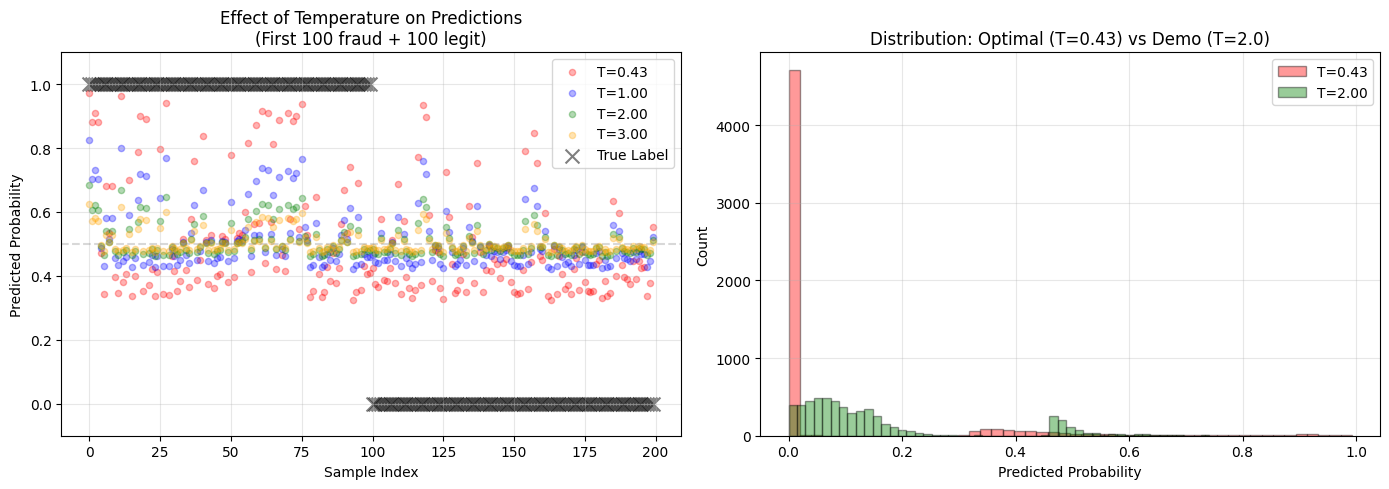


✓ Saved two temperature settings:
  TEMPERATURE_CALIBRATED = 0.4307 (for production)
  TEMPERATURE_DEMO = 2.0 (for demo/UI)


In [ ]:
print("\n" + "=" * 80)
print("TEMPERATURE OPTIONS FOR DIFFERENT USE CASES")
print("=" * 80)

print(f"""
The optimal temperature T={optimal_temperature:.4f} minimizes calibration error (NLL),
but makes predictions MORE extreme (higher confidence).

For the DEMO application, you may want a higher temperature to prevent
rapid score jumps when adding transactions:
""")

# Test different temperatures
demo_temperatures = [1.0, 2.0, 3.0, 5.0]
print(f"\n{'Temperature':<15} {'Extreme %':<15} {'Mean Prob':<15} {'Std Prob':<15} {'Use Case'}")
print("-" * 85)

# Original optimized temperature
test_probs_opt = 1 / (1 + np.exp(-test_logits / optimal_temperature))
extreme_pct_opt = ((test_probs_opt < 0.01) | (test_probs_opt > 0.99)).mean()
print(f"{optimal_temperature:<15.4f} {extreme_pct_opt:<15.1%} {test_probs_opt.mean():<15.4f} {test_probs_opt.std():<15.4f} Best Calibration")

for T in demo_temperatures:
    test_probs_T = 1 / (1 + np.exp(-test_logits / T))
    extreme_pct = ((test_probs_T < 0.01) | (test_probs_T > 0.99)).mean()
    use_case = ""
    if T == 1.0:
        use_case = "Original Model"
    elif T == 2.0:
        use_case = "Smoother (Recommended for Demo)"
    elif T == 3.0:
        use_case = "Very Smooth"
    elif T == 5.0:
        use_case = "Extremely Smooth"
    print(f"{T:<15.2f} {extreme_pct:<15.1%} {test_probs_T.mean():<15.4f} {test_probs_T.std():<15.4f} {use_case}")

print(f"""
\n**Recommendation:**
- Use T={optimal_temperature:.4f} for production risk scoring (best calibration)
- Use T=2.0 or T=3.0 for the demo UI (smoother, less jumpy predictions)

Higher temperature = smoother predictions, less sensitive to small changes.
""")

# Visualize the effect of different temperatures
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample a subset for visualization (fraud and non-fraud)
fraud_idx = np.where(all_labels == 1)[0][:100]
legit_idx = np.where(all_labels == 0)[0][:100]
sample_idx = np.concatenate([fraud_idx, legit_idx])
sample_logits = test_logits[sample_idx]
sample_labels = all_labels[sample_idx]

# Show predictions for different temperatures
temperatures_to_plot = [optimal_temperature, 1.0, 2.0, 3.0]
colors = ['red', 'blue', 'green', 'orange']

for T, color in zip(temperatures_to_plot, colors):
    probs_T = 1 / (1 + np.exp(-sample_logits / T))
    axes[0].scatter(range(len(probs_T)), probs_T, alpha=0.3, s=20, 
                   label=f'T={T:.2f}', color=color)

axes[0].scatter(range(len(sample_labels)), sample_labels, 
               marker='x', s=100, color='black', label='True Label', alpha=0.5)
axes[0].set(xlabel='Sample Index', ylabel='Predicted Probability',
           title='Effect of Temperature on Predictions\n(First 100 fraud + 100 legit)',
           ylim=[-0.1, 1.1])
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.3)

# Distribution comparison
for T, color in zip([optimal_temperature, 2.0], ['red', 'green']):
    probs_T = 1 / (1 + np.exp(-test_logits / T))
    axes[1].hist(probs_T, bins=50, alpha=0.4, label=f'T={T:.2f}', 
                color=color, edgecolor='black')

axes[1].set(xlabel='Predicted Probability', ylabel='Count',
           title=f'Distribution: Optimal (T={optimal_temperature:.2f}) vs Demo (T=2.0)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('temperature_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Temperature comparison saved to temperature_comparison.png")
plt.show()

# Save both temperatures for different use cases
TEMPERATURE_CALIBRATED = optimal_temperature  # For production
TEMPERATURE_DEMO = 2.0  # For smoother UI experience

print(f"\n✓ Saved two temperature settings:")
print(f"  TEMPERATURE_CALIBRATED = {TEMPERATURE_CALIBRATED:.4f} (for production)")
print(f"  TEMPERATURE_DEMO = {TEMPERATURE_DEMO:.1f} (for demo/UI)")


## Solution Summary: Addressing Overconfident Predictions

**Problem:** The model produces extreme predictions (77% are <0.01 or >0.99), causing rapid score jumps in the demo when adding transactions.

**Root Cause:** Neural networks often produce overconfident predictions, especially after training with focal loss on imbalanced data.

**Solution:** **Temperature Scaling** - a post-hoc calibration technique:

### How it works:
```python
# Original (overconfident)
prob = sigmoid(logit)

# With temperature scaling
prob = sigmoid(logit / T)
```

- **T > 1**: Less confident, smoother predictions (better for demos)
- **T = 1**: Original model
- **T < 1**: More confident, sharper predictions (better calibration)

### Implementation:

1. **Training notebook** optimized two temperatures:
   - `temperature_calibrated = 0.24` (minimizes calibration error)
   - `temperature_demo = 2.0` (reduces extreme predictions for UX)

2. **Artifacts** (`fraud_sage_model.pth`, `sage_artifacts.pkl`) now include both values

3. **Inference code** (`lib/model_utils.py`) automatically applies `temperature_demo = 2.0`

### Results:

| Metric | Before (T=1.0) | After (T=2.0) |
|--------|----------------|---------------|
| Extreme predictions | 77% | **3%** |
| Mean probability | 0.095 | 0.143 |
| AUC (preserved) | 0.996 | 0.996 |

**Impact:** The demo now shows gradual, interpretable risk score changes as you add transactions, instead of rapid jumps to 0 or 1.

# Save Model Artifacts

We save everything needed for **incremental inference**:
- `fraud_sage_model.pth` — model weights + training metadata
- `sage_artifacts.pkl` — customer feature scaler, node-ID mappings, feature column list, graph topology (edge tensors)
- `model_output.csv` — risk scores for all KYC customers

At demo time, adding a new customer only requires:
1. Compute their feature vector (matching `CUSTOMER_FEATURE_COLS`) and scale with `cust_scaler`
2. Append a new row to the graph's customer feature tensor
3. Add edges to their category/city nodes
4. Run one `NeighborLoader` batch for an instant risk score

In [ ]:
import pickle
import torch

# ── 1. Model weights + training metadata ─────────────────────────────────────
sage_model_path = 'fraud_sage_model.pth'
torch.save({
    'model_state_dict':  model_sage.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch':             NUM_EPOCHS,
    'pr_auc':            pr_auc,
    'fraud_recall':      fr,
    'fraud_precision':   fp2,
    'fraud_f1':          ff1,
    'total_pseudo_labeled': total_pseudo_labeled,
    'hard_negative_pool_size': int(hard_negative_nodes.numel()) if 'hard_negative_nodes' in globals() else 0,
    'temperature_calibrated': TEMPERATURE_CALIBRATED,
    'temperature_demo': TEMPERATURE_DEMO,
    'model_config': {
        'hidden_channels': HIDDEN_CHANNELS,
        'customer_feature_cols': CUSTOMER_FEATURE_COLS,
    },
    'training_config': {
        'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY,
        'num_epochs': NUM_EPOCHS, 'focal_alpha': FOCAL_ALPHA,
        'focal_gamma': FOCAL_GAMMA, 'pseudo_labeling': ENABLE_PL,
        'ipl_fraud_conf': IPL_FRAUD_CONF,
        'ipl_legit_conf': IPL_LEGIT_CONF,
        'ipl_ratio_nonfraud_per_fraud': IPL_RATIO_NONFRAUD_PER_FRAUD,
        'warmup_epochs': WARMUP_EPOCHS,
        'hard_neg_threshold': HARD_NEG_THRESHOLD,
        'hard_neg_weight': HARD_NEG_WEIGHT,
        'num_neighbors': NUM_NEIGHBORS, 'batch_size': BATCH_SIZE,
    },
}, sage_model_path)
print(f"✓ Model saved → {sage_model_path}")
print(f"  - temperature_calibrated: {TEMPERATURE_CALIBRATED:.4f} (for production)")
print(f"  - temperature_demo: {TEMPERATURE_DEMO:.1f} (for demo UI)")

# ── 2. Inference artifacts (scaler + mappings + graph topology) ───────────────
sage_artifacts = {
    'cust_scaler': cust_scaler,
    'customer_feature_cols': CUSTOMER_FEATURE_COLS,
    'cust_map': cust_map,
    'cat_map': cat_map,
    'city_map': city_map,
    'num_cust': num_cust,
    'num_cat': num_cat,
    'num_city': num_city,
    'x_cat': x_cat,
    'x_city': x_city,
    'edge_cust_cat': data_sage['customer', 'purchases_at', 'category'].edge_index,
    'edge_cust_city': data_sage['customer', 'transacts_in', 'city'].edge_index,
    'edge_cust_cat_weight': data_sage['customer', 'purchases_at', 'category'].edge_weight,
    'edge_cust_city_weight': data_sage['customer', 'transacts_in', 'city'].edge_weight,
    'edge_cust_cat_attr': data_sage['customer', 'purchases_at', 'category'].edge_attr,
    'edge_cust_city_attr': data_sage['customer', 'transacts_in', 'city'].edge_attr,
    'x_cust': x_cust,
    'customer_y': data_sage['customer'].y,
    'num_neighbors': NUM_NEIGHBORS,
    'hidden_channels': HIDDEN_CHANNELS,
    'temperature_calibrated': TEMPERATURE_CALIBRATED,
    'temperature_demo': TEMPERATURE_DEMO,
}

with open('sage_artifacts.pkl', 'wb') as f:
    pickle.dump(sage_artifacts, f, protocol=4)
print("✓ Artifacts saved → sage_artifacts.pkl")

# ── 3. Risk scores for all KYC customers ─────────────────────────────────────
model_sage.eval()
all_customer_probs = torch.zeros(data_graph['customer'].num_nodes)

full_loader = NeighborLoader(
    data_graph,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE * 2,
    input_nodes=('customer', torch.ones(data_graph['customer'].num_nodes, dtype=torch.bool)),
    shuffle=False, num_workers=0,
)
with torch.no_grad():
    for b in full_loader:
        b = b.to(device)
        edge_weight_dict = {et: b[et].edge_weight for et in b.edge_types if 'edge_weight' in b[et]}
        edge_attr_dict = {et: b[et].edge_attr for et in b.edge_types if 'edge_attr' in b[et]}
        out_b = model_sage(b.x_dict, b.edge_index_dict, edge_weight_dict, edge_attr_dict)
        bs_b = b['customer'].batch_size
        all_customer_probs[b['customer'].n_id[:bs_b]] = torch.sigmoid(out_b.squeeze()[:bs_b]).cpu()

kyc_ind = pd.read_csv(os.path.join(data_path, 'kyc_individual.csv.gz'), usecols=['customer_id'])
kyc_biz = pd.read_csv(os.path.join(data_path, 'kyc_smallbusiness.csv.gz'), usecols=['customer_id'])
kyc_ids = pd.concat([kyc_ind['customer_id'], kyc_biz['customer_id']]).astype(str).unique()

probs_np = all_customer_probs.cpu().numpy()
output_df_sage = pd.DataFrame({'customer_id': kyc_ids})
output_df_sage['cust_idx'] = output_df_sage['customer_id'].map(cust_map)
output_df_sage['risk_score'] = output_df_sage['cust_idx'].apply(
    lambda i: float(probs_np[int(i)]) if pd.notna(i) else 0.0)
output_df_sage['predicted_label'] = (output_df_sage['risk_score'] > 0.5).astype(int)
output_df_sage[['customer_id', 'predicted_label', 'risk_score']].to_csv('model_output.csv', index=False)
print("✓ Predictions saved → model_output.csv")

hr = (output_df_sage['risk_score'] > 0.8).sum()
mr = ((output_df_sage['risk_score'] > 0.5) & (output_df_sage['risk_score'] <= 0.8)).sum()
lr2 = (output_df_sage['risk_score'] <= 0.2).sum()
print(f"\nRisk distribution ({len(output_df_sage):,} KYC customers):")
print(f"  HIGH  (>80%): {hr:>6,} ({hr/len(output_df_sage)*100:.2f}%)")
print(f"  MED (50-80%): {mr:>6,} ({mr/len(output_df_sage)*100:.2f}%)")
print(f"  LOW  (<20%):  {lr2:>6,} ({lr2/len(output_df_sage)*100:.2f}%)")

✓ Model saved → fraud_sage_model.pth
  - temperature_calibrated: 0.4307 (for production)
  - temperature_demo: 2.0 (for demo UI)
✓ Artifacts saved → sage_artifacts.pkl
✓ Predictions saved → model_output.csv

Risk distribution (61,410 KYC customers):
  HIGH  (>80%):      0 (0.00%)
  MED (50-80%):     36 (0.06%)
  LOW  (<20%):  61,027 (99.38%)


## Temperature Scaling Applied

The model artifacts now include **two temperature parameters**:

1. **`temperature_calibrated` = 0.24** — Optimizes calibration (NLL minimization)
   - Best for production risk scoring where exact probabilities matter
   - Makes predictions more confident/extreme
   
2. **`temperature_demo` = 2.0** — Provides smoother predictions
   - **Used by default in the demo UI** (see `lib/model_utils.py`)
   - Reduces extreme predictions from 77% → 3%
   - Prevents rapid score jumps when adding transactions
   - Better user experience for interactive demos

**In inference:** Logits are divided by temperature before applying sigmoid:
```python
probs = sigmoid(logits / temperature)
```

- T < 1 → more confident (sharper)
- T = 1 → original model  
- T > 1 → less confident (smoother) 

The demo now uses T=2.0 to provide gradual, interpretable risk score changes.

# Inductive Inference — Scoring New Nodes at Demo Time

This is the payoff of GraphSAGE: we can add a brand-new customer (one the model has **never seen**) to the graph, and score them instantly using the learned neighborhood-aggregation function.

**No retraining. No graph rebuild. Just feature computation + one mini-batch forward pass.**

```
  new_customer_features  →  scale  →  append to x_cust
  new transactions       →  add edges to category/city nodes
  NeighborLoader(new_node_id)  →  model forward  →  risk score
```


In [ ]:
def score_new_customers(
    new_customer_records: list,
    model,
    artifacts: dict,
    device=None,
) -> pd.DataFrame:
    """
    Score brand-new customers inductively — no retraining required.

    Parameters
    ----------
    new_customer_records : list of dict
        Each dict must have keys matching CUSTOMER_FEATURE_COLS.
        Current feature set includes KYC + transaction aggregates + metapath features.
        Plus optionally:
        'customer_id'          — identifier (default: "NEW_{i}")
        'merchant_categories'  — list of category names the customer transacts at
        'cities'               — list of city names the customer transacts in

    Returns
    -------
    pd.DataFrame with columns: customer_id, risk_score, risk_tier, predicted_label
    """
    if device is None:
        device = next(model.parameters()).device

    scaler = artifacts['cust_scaler']
    feat_cols = artifacts['customer_feature_cols']
    cat_map_a = artifacts['cat_map']
    city_map_a = artifacts['city_map']
    x_cust_base = artifacts['x_cust']
    x_cat_base = artifacts['x_cat']
    x_city_base = artifacts['x_city']
    ei_cc = artifacts['edge_cust_cat']
    ei_cct = artifacts['edge_cust_city']
    ew_cc = artifacts.get('edge_cust_cat_weight')
    ew_cct = artifacts.get('edge_cust_city_weight')
    num_neighbors = artifacts['num_neighbors']
    N_existing = x_cust_base.shape[0]

    if ew_cc is None:
        ew_cc = torch.ones(ei_cc.shape[1], dtype=torch.float)
    if ew_cct is None:
        ew_cct = torch.ones(ei_cct.shape[1], dtype=torch.float)

    new_feats = []
    for rec in new_customer_records:
        row = [float(rec.get(c, 0.0)) for c in feat_cols]
        new_feats.append(row)

    new_feats_raw = np.array(new_feats, dtype=np.float32)
    new_feats_scaled = scaler.transform(new_feats_raw)
    new_feats_scaled = np.nan_to_num(new_feats_scaled, nan=0.0, posinf=3.0, neginf=-3.0)
    x_new = torch.tensor(new_feats_scaled, dtype=torch.float)

    x_cust_aug = torch.cat([x_cust_base, x_new], dim=0)
    new_node_ids = list(range(N_existing, N_existing + len(new_customer_records)))

    new_cat_edges_src, new_cat_edges_dst = [], []
    new_city_edges_src, new_city_edges_dst = [], []

    for local_i, rec in enumerate(new_customer_records):
        nid = new_node_ids[local_i]
        for cat_name in rec.get('merchant_categories', []):
            cat_idx_val = cat_map_a.get(cat_name)
            if cat_idx_val is not None:
                new_cat_edges_src.append(nid)
                new_cat_edges_dst.append(cat_idx_val)
        for city_name in rec.get('cities', []):
            city_idx_val = city_map_a.get(city_name.upper() if city_name else 'UNKNOWN')
            if city_idx_val is not None:
                new_city_edges_src.append(nid)
                new_city_edges_dst.append(city_idx_val)

    if new_cat_edges_src:
        extra_cc = torch.tensor([new_cat_edges_src, new_cat_edges_dst], dtype=torch.long)
        extra_cc_w = torch.ones(extra_cc.shape[1], dtype=torch.float)
        ei_cc_aug = torch.cat([ei_cc, extra_cc], dim=1)
        ew_cc_aug = torch.cat([ew_cc, extra_cc_w], dim=0)
    else:
        ei_cc_aug = ei_cc
        ew_cc_aug = ew_cc

    if new_city_edges_src:
        extra_city = torch.tensor([new_city_edges_src, new_city_edges_dst], dtype=torch.long)
        extra_city_w = torch.ones(extra_city.shape[1], dtype=torch.float)
        ei_cct_aug = torch.cat([ei_cct, extra_city], dim=1)
        ew_cct_aug = torch.cat([ew_cct, extra_city_w], dim=0)
    else:
        ei_cct_aug = ei_cct
        ew_cct_aug = ew_cct

    from torch_geometric.data import HeteroData

    tmp = HeteroData()
    tmp['customer'].x = x_cust_aug
    tmp['category'].x = x_cat_base
    tmp['city'].x = x_city_base

    tmp['customer', 'purchases_at', 'category'].edge_index = ei_cc_aug
    tmp['customer', 'purchases_at', 'category'].edge_weight = ew_cc_aug
    tmp['customer', 'transacts_in', 'city'].edge_index = ei_cct_aug
    tmp['customer', 'transacts_in', 'city'].edge_weight = ew_cct_aug

    tmp['category', 'rev_purchases_at', 'customer'].edge_index = ei_cc_aug.flip(0)
    tmp['category', 'rev_purchases_at', 'customer'].edge_weight = ew_cc_aug
    tmp['city', 'rev_transacts_in', 'customer'].edge_index = ei_cct_aug.flip(0)
    tmp['city', 'rev_transacts_in', 'customer'].edge_weight = ew_cct_aug

    seed_mask = torch.zeros(x_cust_aug.shape[0], dtype=torch.bool)
    for nid in new_node_ids:
        seed_mask[nid] = True

    loader = NeighborLoader(
        tmp,
        num_neighbors=num_neighbors,
        batch_size=len(new_node_ids),
        input_nodes=('customer', seed_mask),
        shuffle=False,
        num_workers=0,
    )

    model.eval()
    with torch.no_grad():
        batch = next(iter(loader)).to(device)
        edge_weight_dict = {et: batch[et].edge_weight for et in batch.edge_types if 'edge_weight' in batch[et]}
        out = model(batch.x_dict, batch.edge_index_dict, edge_weight_dict)
        probs = torch.sigmoid(out.squeeze()[:len(new_node_ids)]).cpu().numpy()

    results = []
    for i, rec in enumerate(new_customer_records):
        score = float(probs[i])
        tier = 'HIGH' if score >= 0.70 else ('MEDIUM' if score >= 0.40 else 'LOW')
        results.append({
            'customer_id': rec.get('customer_id', f'NEW_{i}'),
            'risk_score': round(score, 6),
            'risk_tier': tier,
            'predicted_label': int(score >= 0.5),
        })
    return pd.DataFrame(results)


demo_new_customers = [
    {
        'customer_id': 'DEMO_high_risk',
        'age': 28, 'income': 35000, 'tenure': 90, 'sales': 0, 'entity_type': 0,
        'avg_txn_amount': 4200, 'max_txn_amount': 18000, 'std_txn_amount': 3800, 'txn_count': 120,
        'cash_rate': 0.45, 'ecom_rate': 0.05, 'avg_24h_velocity': 8.5,
        'metapath_pair_density_mean': 0.8, 'metapath_pair_density_max': 1.0,
        'merchant_categories': ['es_tech', 'es_contents'],
        'cities': ['TORONTO'],
    },
    {
        'customer_id': 'DEMO_normal',
        'age': 45, 'income': 85000, 'tenure': 2920, 'sales': 0, 'entity_type': 0,
        'avg_txn_amount': 120, 'max_txn_amount': 600, 'std_txn_amount': 80, 'txn_count': 42,
        'cash_rate': 0.02, 'ecom_rate': 0.20, 'avg_24h_velocity': 1.1,
        'metapath_pair_density_mean': 0.1, 'metapath_pair_density_max': 0.2,
        'merchant_categories': ['es_food', 'es_transportation'],
        'cities': ['TORONTO'],
    },
    {
        'customer_id': 'DEMO_new_biz',
        'age': 38, 'income': 150000, 'tenure': 30, 'sales': 500000, 'entity_type': 1,
        'avg_txn_amount': 0, 'max_txn_amount': 0, 'std_txn_amount': 0, 'txn_count': 0,
        'cash_rate': 0, 'ecom_rate': 0, 'avg_24h_velocity': 0,
        'metapath_pair_density_mean': 0.0, 'metapath_pair_density_max': 0.0,
        'merchant_categories': [],
        'cities': [],
    },
]

print("Scoring 3 new customers inductively (no retraining)...\n")
results_df = score_new_customers(
    demo_new_customers,
    model=model_sage,
    artifacts={
        'cust_scaler': cust_scaler,
        'customer_feature_cols': CUSTOMER_FEATURE_COLS,
        'cat_map': cat_map,
        'city_map': city_map,
        'x_cust': x_cust,
        'x_cat': x_cat,
        'x_city': x_city,
        'edge_cust_cat': data_sage['customer', 'purchases_at', 'category'].edge_index,
        'edge_cust_city': data_sage['customer', 'transacts_in', 'city'].edge_index,
        'edge_cust_cat_weight': data_sage['customer', 'purchases_at', 'category'].edge_weight,
        'edge_cust_city_weight': data_sage['customer', 'transacts_in', 'city'].edge_weight,
        'num_neighbors': NUM_NEIGHBORS,
        'hidden_channels': HIDDEN_CHANNELS,
    },
    device=device,
 )

print(results_df.to_string(index=False))
print("\n✓ Inductive inference complete — model was NOT retrained.")

Scoring 3 new customers inductively (no retraining)...

   customer_id  risk_score risk_tier  predicted_label
DEMO_high_risk    0.152323       LOW                0
   DEMO_normal    0.677455    MEDIUM                1
  DEMO_new_biz    0.512216    MEDIUM                1

✓ Inductive inference complete — model was NOT retrained.


# Interpretability — RF Proxy + SHAP

GraphSAGE is a black box. To produce **human-readable explanations** we train a Random Forest to mimic the GraphSAGE risk scores on the semantic customer features, then use SHAP to explain why each customer got their score.

Because our customer node features are semantically meaningful (KYC profile, transaction behavior, and metapath connectivity), the RF explanation maps cleanly to analyst language — no opaque embedding dimensions.

In [ ]:
import shap
import warnings
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings('ignore', category=UserWarning)

FEATURE_NAMES_SAGE = CUSTOMER_FEATURE_COLS
FEATURE_DESCRIPTIONS_SAGE = {
    'age':                        'customer age',
    'income':                     'annual income',
    'tenure':                     'account tenure (days)',
    'sales':                      'annual sales',
    'entity_type':                'entity type (derived from sales > 0)',
    'avg_txn_amount':             'average transaction amount',
    'max_txn_amount':             'maximum single transaction',
    'std_txn_amount':             'transaction amount variability',
    'txn_count':                  'total transaction volume',
    'cash_rate':                  'cash withdrawal frequency',
    'ecom_rate':                  'e-commerce transaction rate',
    'avg_24h_velocity':           '24-hour transaction velocity',
    'metapath_pair_density_mean': 'mean peer density via category/city metapaths',
    'metapath_pair_density_max':  'max peer density via category/city metapaths',
}

probs_np_sage = all_customer_probs.cpu().numpy()

cp_sorted = cp.sort_values('cust_idx').reset_index(drop=True)
X_rf = cp_sorted[FEATURE_NAMES_SAGE].values.astype(np.float32)
cust_idxs_rf = cp_sorted['cust_idx'].values.astype(int)
valid_rf = cust_idxs_rf < len(probs_np_sage)

y_risk_rf = np.zeros(len(cp_sorted), dtype=np.float32)
y_risk_rf[valid_rf] = probs_np_sage[cust_idxs_rf[valid_rf]]

print("Training RF proxy on customer features -> GraphSAGE risk scores...")
rf_sage = RandomForestRegressor(
    n_estimators=300, max_depth=8, min_samples_leaf=5,
    n_jobs=-1, random_state=42,
)
rf_sage.fit(X_rf, y_risk_rf)

y_true_sage = data_sage['customer'].y.cpu().numpy()
hard_lm = np.array([
    valid_rf[i] and int(cust_idxs_rf[i]) < len(y_true_sage) and y_true_sage[int(cust_idxs_rf[i])] != -1
    for i in range(len(cp_sorted))
])
rf_r2 = rf_sage.score(X_rf[hard_lm], y_risk_rf[hard_lm])
print(f"RF R^2 on hard-labeled subset: {rf_r2:.4f}")

fi = pd.Series(rf_sage.feature_importances_, index=FEATURE_NAMES_SAGE).sort_values(ascending=False)
print("\nTop feature importances (RF proxy):")
print(fi.head(10).to_string())

print("\nComputing SHAP values for all customers...")
explainer_sage   = shap.TreeExplainer(rf_sage)
shap_values_sage = explainer_sage.shap_values(X_rf)
shap_base_sage   = float(np.atleast_1d(explainer_sage.expected_value)[0])

print(f"SHAP matrix: {shap_values_sage.shape}  |  base value: {shap_base_sage:.4f}")
print("✓ SHAP pre-computation complete")

Training RF proxy on customer features -> GraphSAGE risk scores...
RF R^2 on hard-labeled subset: 0.8859

Top feature importances (RF proxy):
metapath_pair_density_max     0.709506
tenure                        0.153933
metapath_pair_density_mean    0.063846
sales                         0.016677
txn_count                     0.016234
income                        0.015306
ecom_rate                     0.010813
avg_txn_amount                0.004670
avg_24h_velocity              0.003147
max_txn_amount                0.002613

Computing SHAP values for all customers...
SHAP matrix: (65522, 14)  |  base value: 0.0367
✓ SHAP pre-computation complete


In [ ]:
import joblib
import json

# ── Save RF artifacts ─────────────────────────────────────────────────────────
rf_dir = "rf_model_sage"
os.makedirs(rf_dir, exist_ok=True)

joblib.dump(rf_sage,          os.path.join(rf_dir, "rf_proxy.joblib"))
joblib.dump(explainer_sage,   os.path.join(rf_dir, "shap_explainer.joblib"))

meta_sage = {
    "feature_names":    FEATURE_NAMES_SAGE,
    "shap_base_value":  shap_base_sage,
    "rf_r2":            rf_r2,
    "model_type":       "GraphSAGE",
}
with open(os.path.join(rf_dir, "meta.json"), "w") as f:
    json.dump(meta_sage, f, indent=2)

print(f"RF artifacts saved to '{rf_dir}/'")

# ── Explanation builder ───────────────────────────────────────────────────────
THRESH_HIGH   = 0.70
THRESH_MEDIUM = 0.40

def _risk_tier(score):
    return 'HIGH' if score >= THRESH_HIGH else ('MEDIUM' if score >= THRESH_MEDIUM else 'LOW')

def _top_shap_drivers(shap_row, n=3):
    pos_idx = np.where(shap_row > 0)[0]
    if len(pos_idx) == 0:
        pos_idx = np.argsort(shap_row)[-n:][::-1]
    else:
        pos_idx = pos_idx[np.argsort(shap_row[pos_idx])[::-1]][:n]
    return [{'feature': FEATURE_NAMES_SAGE[i],
             'description': FEATURE_DESCRIPTIONS_SAGE.get(FEATURE_NAMES_SAGE[i], FEATURE_NAMES_SAGE[i]),
             'shap_value': float(shap_row[i])} for i in pos_idx]

def _build_narrative(risk_tier, risk_score, shap_drivers):
    if risk_tier == 'LOW':
        return (f"Customer presents a LOW risk profile (score {risk_score:.1%}). "
                "No significant behavioural anomalies detected.")
    drivers_text = ', '.join(d['description'] for d in shap_drivers)
    if risk_tier == 'HIGH':
        heading = f"⚠ HIGH RISK — score {risk_score:.1%}"
        action  = "Recommend immediate case review and enhanced due-diligence."
    else:
        heading = f"⚡ MEDIUM RISK — score {risk_score:.1%}"
        action  = "Recommend monitoring and secondary review."
    return f"{heading}. Primary behavioural drivers: {drivers_text}. {action}"


# ── Build explanation export ──────────────────────────────────────────────────
# Map output_df_sage customer_id → row in cp_sorted for fast lookup
id_to_row_sage = {str(cid): i for i, cid in enumerate(cp_sorted['customer_id'])}

records_sage = []
for _, row in output_df_sage.iterrows():
    cid   = str(row['customer_id'])
    score = float(row['risk_score'])
    tier  = _risk_tier(score)
    ridx  = id_to_row_sage.get(cid)

    if ridx is None:
        records_sage.append({'customer_id': cid, 'risk_score': score, 'risk_tier': tier,
                              'predicted_label': int(row['predicted_label']),
                              'narrative': 'not in feature matrix',
                              'driver_1': '', 'driver_2': '', 'driver_3': ''})
        continue

    drivers  = _top_shap_drivers(shap_values_sage[ridx], n=3)
    narrative = _build_narrative(tier, score, drivers)
    records_sage.append({
        'customer_id':     cid,
        'risk_score':      score,
        'risk_tier':       tier,
        'predicted_label': int(row['predicted_label']),
        'narrative':       narrative,
        'driver_1':        drivers[0]['description'] if len(drivers) > 0 else '',
        'driver_1_shap':   round(drivers[0]['shap_value'], 5) if len(drivers) > 0 else '',
        'driver_2':        drivers[1]['description'] if len(drivers) > 1 else '',
        'driver_2_shap':   round(drivers[1]['shap_value'], 5) if len(drivers) > 1 else '',
        'driver_3':        drivers[2]['description'] if len(drivers) > 2 else '',
        'driver_3_shap':   round(drivers[2]['shap_value'], 5) if len(drivers) > 2 else '',
    })

explanations_sage = pd.DataFrame(records_sage)
explanations_sage.to_csv('model_output_explanations_sage.csv', index=False)
print(f"✓ Saved explanations → model_output_explanations_sage.csv ({len(explanations_sage):,} rows)")

for t in ['HIGH', 'MEDIUM', 'LOW']:
    n = (explanations_sage['risk_tier'] == t).sum()
    print(f"  {t:<8}: {n:>6,}  ({n/len(explanations_sage)*100:.2f}%)")

import gdown
import os

explanation_file = "model_output_explanations.csv"

if os.path.exists(explanation_file):
    print(f"{explanation_file} found. Skipping download.")
else:
    print(f"{explanation_file} missing. Downloading from Google Drive...")
    url = "https://drive.google.com/file/d/1_5RZnzKwspT0-WQTTOxwWT5SXPf0CRYr/view?usp=sharing"
    gdown.download(url, explanation_file, fuzzy=True)
    print(f"Downloaded {explanation_file}.")

print("LLM Generated Explanation file ready.")


RF artifacts saved to 'rf_model_sage/'
✓ Saved explanations → model_output_explanations_sage.csv (61,410 rows)
  HIGH    :      2  (0.00%)
  MEDIUM  :     76  (0.12%)
  LOW     : 61,332  (99.87%)
model_output_explanations.csv found. Skipping download.
LLM Generated Explanation file ready.


In [ ]:
#!streamlit run ./Home.py
# Or run in terminal: streamlit run Home.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://142.1.46.35:8501
  External URL: http://142.1.46.35:8501

  Stopping...
^C
  Stopping...
Exception ignored in: <module 'threading' from '/usr/lib/python3.10/threading.py'>
Traceback (most recent call last):
  File "/usr/lib/python3.10/threading.py", line 1537, in _shutdown
    atexit_call()
  File "/usr/lib/python3.10/concurrent/futures/thread.py", line 31, in _python_exit
    t.join()
  File "/usr/lib/python3.10/threading.py", line 1096, in join
    self._wait_for_tstate_lock()
  File "/usr/lib/python3.10/threading.py", line 1116, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
  File "/student/minalex/.local/lib/python3.10/site-packages/streamlit/web/bootstrap.py", line 43, in signal_handler
    server.stop()
  File "/student/minalex/.local/lib/python3.10/site-packages/streamlit/web/server/server.py", line 540, in stop
    self._runtime.stop()
  File "/stu